### 物性値予測

教師あり学習の手法を適用

#### BASEデータセット

$\beta$-セクレターゼ1 (BASE1)と呼ばれる酵素に対する阻害剤の構造式 & ${\rm IC}_{50}$の値

In [2]:
# MoleculeNetを使用するためのdeepchemライブラリを使用
# PyTorchと連携できるバージョン

!pip install deepchem[torch]

train_set: 
   X_shape    y_shape
0  (1210,)  (1210, 1)
val_set: 
  X_shape   y_shape
0  (151,)  (151, 1)
test_set: 
  X_shape   y_shape
0  (152,)  (152, 1)
y_mean, y_std = -3.429396344495029e-15, 0.9999999999999992


Text(0.5, 0, 'Normalized pIC50')

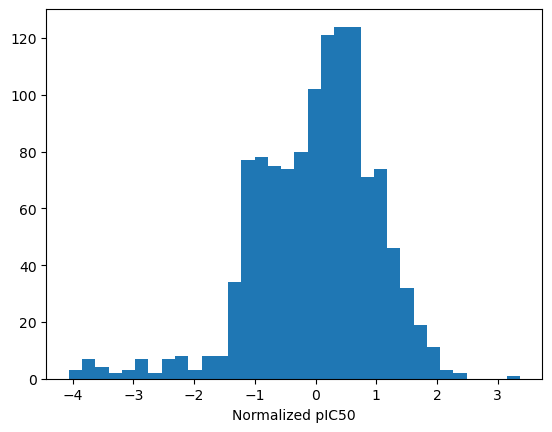

In [5]:
# 目的変数の可視化

import matplotlib.pyplot as plt
import numpy as np
import deepchem as dc

# featurizer = dc.feat.RDKitDescriptors()
# tasks, datasets, transformers = dc.molnet.load_bace_regression(featurizer)
tasks, datasets, transformers = dc.molnet.load_bace_regression(featurizer='GraphConv', splitter='index')
train_set, val_set, test_set = datasets
print('train_set: \n{}'.format(train_set.metadata_df.iloc[:, 5:7]))
print('val_set: \n{}'.format(val_set.metadata_df.iloc[:, 5:7]))
print('test_set: \n{}'.format(test_set.metadata_df.iloc[:, 5:7]))
print('y_mean, y_std = {}, {}'.format(np.mean(train_set.y), np.std(train_set.y)))

plt.hist(train_set.y, bins=int(np.sqrt(len(train_set.y))))
plt.xlabel('Normalized pIC50')

# IC50のヒストグラム

step: 0,		train loss: 3.363368556125105
step: 0,		val loss: 2.375647159601679
step: 100,		train loss: 0.863658597646666
step: 100,		val loss: 0.6093052112503557
step: 200,		train loss: 0.6288327658471983
step: 200,		val loss: 0.6074958826532427
step: 300,		train loss: 0.5232409540286734
step: 300,		val loss: 0.44809986266079327
step: 400,		train loss: 0.5222832648222111
step: 400,		val loss: 0.7514963086867175
step: 500,		train loss: 0.48288267387831507
step: 500,		val loss: 0.664681895679196
step: 600,		train loss: 0.531780899457695
step: 600,		val loss: 0.33791194372619227
step: 700,		train loss: 0.47359382928895555
step: 700,		val loss: 0.3384146090374877
step: 800,		train loss: 0.3793531473017921
step: 800,		val loss: 0.4904697809787775
step: 900,		train loss: 0.7468872614143308
step: 900,		val loss: 1.1973148244895682
step: 1000,		train loss: 0.35266050898339135
step: 1000,		val loss: 0.41865125870862546
step: 1100,		train loss: 0.3438322745078851
step: 1100,		val loss: 0.43139348

Text(0, 0.5, 'True normalized pIC50')

<Figure size 1500x600 with 0 Axes>

<Figure size 640x480 with 0 Axes>

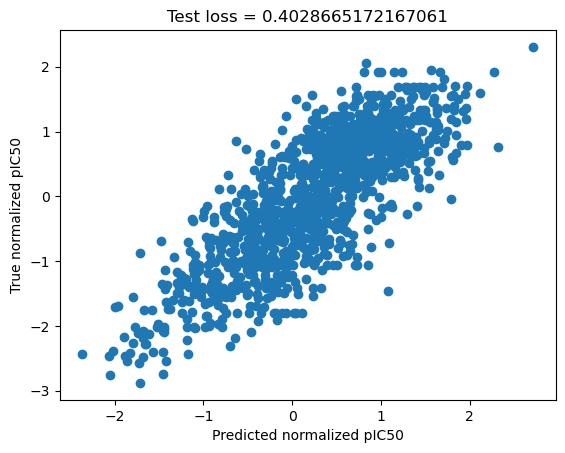

In [6]:
# ニューラルネットワークを用いた予測モデルの構築

import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
from fnn import FeedforwardNeuralNetwork

torch.manual_seed(43)

def loss_evaluator(dataloader, model, loss_func):
    sample_size = len(dataloader.dataset)
    pred_list = []
    true_list = []
    with torch.no_grad():
        loss = 0
        for each_X, each_y in dataloader:
            each_pred = model.forward(each_X)
            pred_list.extend(each_pred.tolist())
            true_list.extend(each_y.tolist())
            loss += loss_func(each_pred, each_y).item()
    return loss / sample_size, pred_list, true_list

featurizer = dc.feat.RDKitDescriptors()
tasks, datasets, transformers = dc.molnet.load_bace_regression(featurizer)

train_set, val_set, test_set = datasets
train_dataloader = DataLoader(
    TensorDataset(
        torch.FloatTensor(train_set.X),
        torch.FloatTensor(train_set.y)),
    batch_size=32, shuffle=True)
val_dataloader = DataLoader(
    TensorDataset(torch.FloatTensor(val_set.X),
                  torch.FloatTensor(val_set.y)),
    batch_size=32,
    shuffle=True)
test_dataloader = DataLoader(
    TensorDataset(torch.FloatTensor(test_set.X),
                  torch.FloatTensor(test_set.y)),
    batch_size=32,
    shuffle=True)

model = FeedforwardNeuralNetwork(in_dim=train_set.X.shape[1], hidden_dim=32)
loss_func = nn.MSELoss(reduction='sum')
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
n_step = 0
train_loss_list = []
val_loss_list = []
for each_epoch in range(30):
    for each_X, each_y in train_dataloader:
        if n_step % 10 == 0:
            train_loss, _, _ = loss_evaluator(train_dataloader, model, loss_func)
            val_loss, _, _ = loss_evaluator(val_dataloader, model, loss_func)
            if n_step % 100 == 0:
                print('step: {},\t\ttrain loss: {}'.format(n_step, train_loss))
                print('step: {},\t\tval loss: {}'.format(n_step, val_loss))
            train_loss_list.append((n_step, train_loss))
            val_loss_list.append((n_step, val_loss))

        each_pred = model.forward(each_X)
        loss = loss_func(each_pred, each_y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        n_step += 1


fig, ax = plt.subplots(1, 1)
ax.plot(*list(zip(*train_loss_list)), marker='+')
ax.plot(*list(zip(*val_loss_list)), marker='.')
ax.set_title('Learning curve')
ax.set_xlabel('# of updates')
ax.set_ylabel('Loss')
ax.set_yscale('log')
plt.savefig('bace_loss.pdf')
plt.clf()

test_loss, pred_list, true_list = loss_evaluator(train_dataloader, model, loss_func)
print('test_loss: {}'.format(test_loss))

fig, ax = plt.subplots(1, 1)
ax.scatter(pred_list, true_list)
ax.set_title('Test loss = {}'.format(test_loss))
ax.set_xlabel('Predicted normalized pIC50')
ax.set_ylabel('True normalized pIC50')

# 大して複雑でもないのに割と正確な予測